# Rolling five-minute seizure forecasting from scalp EEG

This notebook assesses and implements a **rolling five-minute, discrete-time seizure forecast** from pre-recorded EDF scalp EEG. It reads two minutes of strictly past EEG context and evaluates only at five-second boundaries. After a boundary is crossed, the elapsed rectangle disappears and a new five-second rectangle is appended at the far end, so every update still covers exactly five minutes.

The output is a proper distribution over 60 possible onset intervals **plus an explicit no-seizure-in-the-next-five-minutes outcome**. A second timing-only view normalizes the 60 bars conditional on a seizure occurring within the current rolling horizon.

> **Research-only warning:** this small retrospective dataset and model are not validated for diagnosis, treatment, patient warning, or any clinical decision.

In [1]:
from pathlib import Path
import json
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / 'rolling_seizure_forecasting.py').exists():
    candidates = list(NOTEBOOK_DIR.rglob('rolling_seizure_forecasting.py'))
    if len(candidates) != 1:
        raise FileNotFoundError('Run this notebook from its scripts directory or repository root.')
    NOTEBOOK_DIR = candidates[0].parent
sys.path.insert(0, str(NOTEBOOK_DIR))

import rolling_seizure_forecasting as rsf

paths = rsf.project_paths(NOTEBOOK_DIR)
config = rsf.ForecastConfig()
config.validate()
paths['processed'].mkdir(parents=True, exist_ok=True)
paths['results'].mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')
print(f'Module version: {rsf.MODULE_VERSION}')
print(f'Raw data: {paths["raw"]}')
print(f'Results:  {paths["results"]}')

Module version: 2.0.0
Raw data: C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-optimizers-analysis\final_project\data\raw
Results:  C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-optimizers-analysis\final_project\results\rolling_forecast


## 1. Mathematical assessment

Let $\Delta=5$ seconds and $K=300/5=60$. At landmark $t$, define the discrete conditional hazard

$$h_j(x_t)=P\{T\in(t+(j-1)\Delta,t+j\Delta]\mid T>t+(j-1)\Delta,x_t\}.$$

The onset probability mass in bin $j$ and the no-event mass are

$$p_j=h_j\prod_{r<j}(1-h_r),\qquad p_{\varnothing}=\prod_{r=1}^{K}(1-h_r).$$

Therefore $\sum_{j=1}^{K}p_j+p_{\varnothing}=1$. This is mathematically consistent and guarantees a non-increasing survival curve.

The original proposal—forcing only the 60 seizure-time bins to sum to one—is consistent **only conditional on a seizure being certain in five minutes**. For ordinary interictal EEG that assumption is false. The useful display is instead

$$P(T\text{ in bin }j\mid T\le t+300,x_t)=\frac{p_j}{1-p_{\varnothing}},$$

shown beside the absolute five-minute event risk $1-p_{\varnothing}$. If rectangle heights represent a density, the Riemann sum is $\sum_j f_j\Delta=1$; if rectangles are labeled with probability mass $p_j$, then $\sum_jp_j=1$. Those conventions should not be mixed.

The replay begins only after 120 seconds of past context. At times $t_m=t_0+m\Delta$, the active forecast always contains intervals $(t_m,t_m+\Delta],\ldots,(t_m+295,t_m+300]$. Crossing one boundary expires the first interval and appends $(t_m+300,t_m+305]$ at the right. Thus the support moves forward by exactly one bin and remains 60 bins wide.

Each landmark is a fresh forecast from EEG ending at that landmark, not a passive renormalization of the preceding graph. Because the data are prerecorded, all causal five-second features and all landmark forecasts are computed once in a batch; displaying the next state is then a cached lookup.

## 2. Loss function

The implemented loss is the discrete survival negative log-likelihood, expressed as binary cross-entropy over only the bins for which a landmark is at risk. If onset occurs in bin $k$,

$$\mathcal L=-\log h_k-\sum_{j<k}\log(1-h_j).$$

If no onset is observed during the five-minute follow-up,

$$\mathcal L=-\sum_{j=1}^{K}\log(1-h_j).$$

This naturally handles the no-event outcome and produces a normalized distribution. A direct alternative is 61-class cross-entropy over 60 onset bins plus no-event. The hazard parameterization is preferable here because it encodes survival monotonicity and can later accommodate right-censoring. Class weighting or focal loss should not be added casually: both can damage probability calibration. If used for optimization, probabilities should be recalibrated on a separate validation set.

## 3. Recommended evaluation

| Quantity | Definition and use |
|---|---|
| Seizure sensitivity | Fraction of seizure episodes receiving at least one pre-onset warning. Report patient-level uncertainty. |
| Time in warning (TiW) | Fraction of eligible monitored time for which the warning is active. Sensitivity must be interpreted against TiW. |
| False alarms/hour | Rising warning edges during interictal follow-up divided by interictal hours. State warning persistence/refractory rules. |
| Multicategory Brier score | Proper score across the 60 onset bins plus no-event. Lower is better. |
| Integrated survival Brier score | Mean squared survival-probability error across all 60 endpoints. |
| Brier skill score | Improvement over a prespecified baseline forecast; values above zero are better than baseline. |
| Calibration/reliability | Compare forecasted and observed event frequencies; AUROC alone cannot establish calibration. |
| Negative log-likelihood | Strictly proper score that strongly penalizes confident errors. |
| Sensitivity–TiW curve / AUROC | Threshold-free operational discrimination. Use seizure-time surrogates for a chance benchmark. |
| Conditional timing MAE | Error in expected onset time given that an event occurs; always report it separately from event risk. |

Metrics and warning thresholds must be computed on continuous, chronologically held-out data. This notebook uses a patient-disjoint holdout and chooses its warning threshold on development patients only, but the available recordings are still too short for a clinically stable false-alarm estimate.

## 4. Closely related approaches

- [DeepHit (Lee et al., 2018)](https://doi.org/10.1609/aaai.v32i1.11842) directly learns a probability mass function over discrete event times; it is the closest general time-to-event analogue to 60 future rectangles.
- [Dynamic-DeepHit (Lee, Yoon & van der Schaar, 2020)](https://doi.org/10.1109/TBME.2019.2909027) updates discrete time-to-event distributions from longitudinal measurements, closely matching scheduled landmark updates.
- [Nnet-survival (Gensheimer & Narasimhan, 2019)](https://doi.org/10.7717/peerj.6257) estimates interval-specific conditional hazards with a neural likelihood; this is the loss used here with a smaller tree model suitable for 47 seizures.
- [McKinsey et al. (2022)](https://doi.org/10.1080/24725579.2022.2051645) used random survival forests to estimate seizure-onset hazard across a prediction horizon, including a five-minute horizon, although their evaluation was in animal EEG rather than human scalp EEG.
- [EEGSurvNet (Lemoine et al., 2026)](https://doi.org/10.1002/epi.70101) predicts time to a future seizure from routine human EEG using six discrete hazard intervals. Its horizon is long-term recurrence, not minutes-before-onset forecasting, but its output construction is directly relevant.
- [Winterhalder et al. (2003)](https://doi.org/10.1016/S1525-5050(03)00105-7) formalized seizure-prediction assessment using sensitivity and false prediction rate.
- [Proix et al. (2021)](https://doi.org/10.1016/S1474-4422(20)30396-3) evaluated probabilistic seizure forecasts on unseen data with sensitivity versus time in warning and Brier skill score.
- [Kuhlmann et al. (2018)](https://pubmed.ncbi.nlm.nih.gov/30131521/) review methodological requirements and clinical translation pitfalls for seizure prediction.

The exact combination here—human scalp EEG, five-second bins, scheduled rolling updates, and an appended far-right bin—is an adaptation of dynamic discrete-time survival forecasting rather than a standard established seizure-prediction protocol.

## 5. Read and audit the EDF study

The project already contains an audited `event_inventory.csv` derived from the Siena scalp EEG annotations. The model reads voltage samples directly from the raw EDF files. Positive episodes begin 300 seconds before each annotated onset. A matched interictal episode is selected for the same patient, with two minutes of context, five minutes of displayed follow-up, another five minutes needed to label the last landmark, and a five-minute buffer around every annotated seizure.

In [2]:
edf_files = sorted(paths['raw'].rglob('*.edf'))
saved_manifest_path = paths['results'] / 'episode_manifest.csv'
if paths['event_inventory'].exists():
    events = rsf.load_event_inventory(paths['event_inventory'])
    manifest = rsf.build_episode_manifest(events, paths['raw'], config)
elif saved_manifest_path.exists():
    # The saved audited manifest makes the executed notebook reproducible
    # even when upstream generated audit tables are not present locally.
    manifest = pd.read_csv(saved_manifest_path)
    manifest = manifest.rename(columns={'fixed_end_seconds': 'training_episode_end_seconds'})
    positive_manifest = manifest.loc[manifest['episode_type'].eq('preictal')].copy()
    events = pd.DataFrame({
        'patient_id': positive_manifest['patient_id'],
        'event_id': positive_manifest['source_event_id'],
        'recording': positive_manifest['recording'],
        'onset_seconds': positive_manifest['event_onset_seconds'],
        'seizure_duration_seconds': np.nan,
        'eligible_preictal': True,
    }).reset_index(drop=True)
    print('Upstream event inventory was unavailable; reused the saved audited episode manifest.')
else:
    raise FileNotFoundError('Neither event_inventory.csv nor the saved episode manifest is available.')

study_summary = pd.DataFrame({
    'quantity': [
        'patients', 'EDF recordings', 'annotated seizures', 'eligible seizures',
        'preictal episodes', 'matched interictal episodes', 'bin width (s)',
        'horizon (s)', 'past EEG context (s)', 'total EDF size (GB)'
    ],
    'value': [
        events['patient_id'].nunique(), len(edf_files), len(events),
        int(events['eligible_preictal'].sum()),
        int(manifest['episode_type'].eq('preictal').sum()),
        int(manifest['episode_type'].eq('interictal').sum()),
        config.bin_seconds, config.horizon_seconds, config.context_seconds,
        round(sum(path.stat().st_size for path in edf_files) / 1e9, 2),
    ]
})
display(study_summary)
display(manifest.groupby(['patient_id', 'episode_type']).size().unstack(fill_value=0))
display(manifest.head(8))

Upstream event inventory was unavailable; reused the saved audited episode manifest.


,quantity,value
0,patients,14.0
1,EDF recordings,41.0
2,annotated seizures,47.0
3,eligible seizures,47.0
4,preictal episodes,47.0
5,matched interictal episodes,47.0
6,bin width (s),5.0
7,horizon (s),300.0
8,past EEG context (s),120.0
9,total EDF size (GB),21.8


episode_type,interictal,preictal
patient_id,,
PN00,5,5
PN01,2,2
PN03,2,2
PN05,3,3
PN06,5,5
PN07,1,1
PN09,3,3
PN10,10,10
PN11,1,1


,episode_id,patient_id,source_event_id,episode_type,recording,edf_path,anchor_seconds,training_episode_end_seconds,event_onset_seconds
0,PN00_interictal_01,PN00,NaN,interictal,PN00-1.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,120.0,420.0,NaN
1,PN00_interictal_02,PN00,NaN,interictal,PN00-1.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,1860.0,2160.0,NaN
2,PN00_interictal_03,PN00,NaN,interictal,PN00-3.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,1260.0,1560.0,NaN
3,PN00_interictal_04,PN00,NaN,interictal,PN00-3.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,1680.0,1980.0,NaN
4,PN00_interictal_05,PN00,NaN,interictal,PN00-5.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,1500.0,1800.0,NaN
5,PN00_S01_preictal,PN00,PN00_S01,preictal,PN00-1.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,843.0,1143.0,1143.0
6,PN00_S02_preictal,PN00,PN00_S02,preictal,PN00-2.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,920.0,1220.0,1220.0
7,PN00_S03_preictal,PN00,PN00_S03,preictal,PN00-3.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,465.0,765.0,765.0


## 6. Causal EEG features at each landmark

Each five-second micro-window is detrended and robustly common-median referenced. Implausibly flat or extreme channels are rejected. The signal is resampled to 128 Hz, and robust scalp summaries are calculated for relative and log absolute power in delta, theta, alpha, beta, and 30–45 Hz low gamma, plus RMS, line length, spectral entropy, and usable-channel fraction. The preceding 24 micro-windows are summarized by mean, standard deviation, latest value, and slope, giving 56 features.

Only samples strictly before the landmark are used. The cache below contains derived features, never altered raw EDF data.

In [3]:
cache_csv = paths['processed'] / 'landmark_features.csv'
cache_metadata = paths['processed'] / 'landmark_features_metadata.json'
started = time.time()
landmarks = rsf.build_landmark_dataset(
    manifest,
    cache_csv=cache_csv,
    cache_metadata_json=cache_metadata,
    config=config,
    force=False,
    verbose=True,
)
print(f'Feature table: {landmarks.shape[0]:,} landmarks x {len(rsf.MODEL_FEATURE_COLUMNS)} model features')
print(f'Elapsed: {time.time() - started:.1f} seconds')

feature_audit = pd.DataFrame({
    'check': ['expected row count', 'finite model features', '60 landmarks per episode', 'both target types present'],
    'passed': [
        len(landmarks) == len(manifest) * rsf.N_BINS,
        np.isfinite(landmarks[rsf.MODEL_FEATURE_COLUMNS].to_numpy()).all(),
        landmarks.groupby('episode_id').size().eq(rsf.N_BINS).all(),
        landmarks['has_event_in_5m'].nunique() == 2,
    ]
})
assert feature_audit['passed'].all(), feature_audit
display(feature_audit)
display(landmarks[['episode_id', 'patient_id', 'episode_type', 'landmark_step', 'time_to_event_seconds', 'event_bin'] + rsf.MODEL_FEATURE_COLUMNS[:6]].head(10))

Loaded 5,640 cached landmark rows.
Feature table: 5,640 landmarks x 56 model features
Elapsed: 0.0 seconds


,check,passed
0,expected row count,True
1,finite model features,True
2,60 landmarks per episode,True
3,both target types present,True


,episode_id,patient_id,episode_type,landmark_step,time_to_event_seconds,event_bin,relative_delta_mean,relative_delta_std,relative_delta_last,relative_delta_slope,relative_theta_mean,relative_theta_std
0,PN00_interictal_01,PN00,interictal,0,NaN,-1,0.698608,0.070337,0.778002,0.000826,0.081961,0.026852
1,PN00_interictal_01,PN00,interictal,1,NaN,-1,0.693351,0.075046,0.567785,0.000554,0.082803,0.027365
2,PN00_interictal_01,PN00,interictal,2,NaN,-1,0.682735,0.081418,0.513694,0.000358,0.085090,0.027010
3,PN00_interictal_01,PN00,interictal,3,NaN,-1,0.687222,0.078362,0.684402,0.000131,0.085644,0.027404
4,PN00_interictal_01,PN00,interictal,4,NaN,-1,0.694937,0.082742,0.829389,0.000322,0.082537,0.028618
5,PN00_interictal_01,PN00,interictal,5,NaN,-1,0.693579,0.084165,0.590489,-0.000044,0.082252,0.028394
6,PN00_interictal_01,PN00,interictal,6,NaN,-1,0.690450,0.086183,0.599531,-0.000273,0.082490,0.028541
7,PN00_interictal_01,PN00,interictal,7,NaN,-1,0.694700,0.083487,0.689758,-0.000497,0.082406,0.028466
8,PN00_interictal_01,PN00,interictal,8,NaN,-1,0.694574,0.083526,0.667259,-0.000605,0.081646,0.027895
9,PN00_interictal_01,PN00,interictal,9,NaN,-1,0.692821,0.084013,0.649377,-0.000703,0.083046,0.029581


## 7. Patient-disjoint training and probability checks

All overlapping landmarks from one patient stay in one split. The nonlinear gradient-boosted hazard model is intentionally compact: 47 seizures do not justify a large raw-waveform neural network. The estimator is trained by the same Bernoulli log-likelihood as a discrete survival neural network and can be replaced later without changing targets, forecast logic, or metrics.

In [4]:
development, holdout, split = rsf.split_by_patient(landmarks, config)
print('Development patients:', ', '.join(split['development_patients']))
print('Holdout patients:    ', ', '.join(split['holdout_patients']))
print(f'Development landmarks: {len(development):,}; holdout landmarks: {len(holdout):,}')

started = time.time()
model = rsf.fit_hazard_model(development, config)
print(f'Model fitted in {time.time() - started:.1f} seconds; boosting iterations: {model.n_iter_}')

hazards_check, pmf_check, no_event_check = rsf.predict_horizon_distribution(model, holdout.head(32))
invariants = pd.Series(rsf.probability_invariants(hazards_check, pmf_check, no_event_check), name='passed').to_frame()
assert invariants['passed'].all(), invariants
display(invariants)

Development patients: PN01, PN03, PN05, PN06, PN07, PN09, PN10, PN11, PN13, PN17
Holdout patients:     PN00, PN12, PN14, PN16
Development landmarks: 3,840; holdout landmarks: 1,800


Model fitted in 31.0 seconds; boosting iterations: 120


,passed
hazards_are_probabilities,True
pmf_is_nonnegative,True
no_event_is_probability,True
mass_sums_to_one,True
survival_is_monotone,True


## 8. Holdout performance and readable artifacts

The warning threshold is selected on development patients only, targeting at most 25% time in warning when feasible. The following numbers measure this retrospective case-control construction; they are **not estimates of real-world calibrated risk**.

In [5]:
(
    holdout_predictions,
    metrics,
    patient_metrics,
    warning_threshold,
    threshold_curve,
) = rsf.evaluate_forecasts(
    model,
    development,
    holdout,
    warning_time_target=config.warning_time_target,
)

display(metrics.style.format({'value': '{:.4f}'}))
display(patient_metrics.style.format(precision=3))

study_summary.to_csv(paths['results'] / 'study_summary.csv', index=False)
manifest.to_csv(paths['results'] / 'episode_manifest.csv', index=False)
metrics.to_csv(paths['results'] / 'holdout_metrics.csv', index=False)
patient_metrics.to_csv(paths['results'] / 'holdout_patient_metrics.csv', index=False)
threshold_curve.to_csv(paths['results'] / 'development_warning_curve.csv', index=False)
holdout_predictions.to_csv(paths['results'] / 'holdout_landmark_probabilities.csv', index=False)
model_path = rsf.save_model_bundle(
    paths['results'] / 'rolling_discrete_hazard_model.joblib',
    model,
    config,
    warning_threshold,
    split,
    metrics,
)
print(f'Saved model: {model_path}')

,metric,value,interpretation
0,negative log likelihood,3.1443,Lower is better; proper score for the observed bin/no-event class.
1,multicategory Brier score,0.8204,Lower is better; probability error across 60 bins plus no-event.
2,multicategory Brier skill score,-0.1000,Above 0 improves on the development-set class-frequency forecast.
3,integrated survival Brier score,0.1900,Lower is better; mean survival-probability error across 5 minutes.
4,5-minute AUROC,0.5446,Discrimination only; does not assess calibration.
5,5-minute average precision,0.5857,Ranking metric sensitive to event prevalence.
6,conditional timing MAE (seconds),74.1461,Error of expected onset time among seizure landmarks.
7,seizure sensitivity,0.3333,Fraction of seizure episodes with at least one warning.
8,time in warning,0.0744,Fraction of evaluated five-second landmarks under warning.
9,false alarms per hour,10.4000,Rising warning edges in interictal episodes per monitored hour.


,patient_id,landmarks,seizure_episodes,interictal_episodes,auroc,sensitivity,time_in_warning,false_alarms_per_hour,captured_seizures,total_seizures,median_warning_lead_seconds
0,PN00,600,5,5,0.636,0.200,0.015,7.200,1.000,5.000,270.000
1,PN12,480,4,4,0.662,0.750,0.212,24.000,3.000,4.000,265.000
2,PN14,480,4,4,0.477,0.250,0.037,0.000,1.000,4.000,240.000
3,PN16,240,2,2,0.186,0.000,0.021,12.000,0.000,2.000,nan


Saved model: C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-optimizers-analysis\final_project\results\rolling_forecast\rolling_discrete_hazard_model.joblib


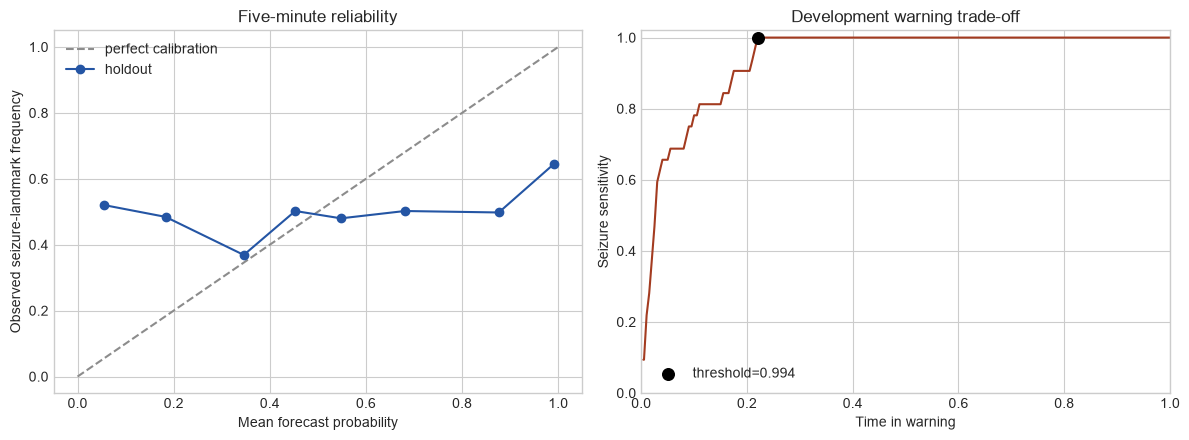

,mean_forecast,observed_frequency,landmarks
0,0.056031,0.520000,225
1,0.183043,0.484444,225
2,0.345834,0.368889,225
3,0.452857,0.502222,225
4,0.547990,0.480000,225
5,0.680845,0.502222,225
6,0.876275,0.497778,225
7,0.990591,0.644444,225


In [6]:
calibration = holdout_predictions[['event_risk_5m', 'has_event_in_5m']].copy()
calibration['risk_group'] = pd.qcut(calibration['event_risk_5m'], q=8, duplicates='drop')
calibration_summary = calibration.groupby('risk_group', observed=True).agg(
    mean_forecast=('event_risk_5m', 'mean'),
    observed_frequency=('has_event_in_5m', 'mean'),
    landmarks=('has_event_in_5m', 'size'),
).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot([0, 1], [0, 1], '--', color='0.55', label='perfect calibration')
axes[0].plot(calibration_summary['mean_forecast'], calibration_summary['observed_frequency'], 'o-', color='#2455A4', label='holdout')
axes[0].set(xlabel='Mean forecast probability', ylabel='Observed seizure-landmark frequency', title='Five-minute reliability')
axes[0].legend()

curve = threshold_curve.sort_values('time_in_warning')
axes[1].plot(curve['time_in_warning'], curve['sensitivity'], color='#A33B20')
selected = curve.iloc[(curve['threshold'] - warning_threshold).abs().argmin()]
axes[1].scatter([selected['time_in_warning']], [selected['sensitivity']], s=70, color='black', zorder=3, label=f'threshold={warning_threshold:.3f}')
axes[1].set(xlabel='Time in warning', ylabel='Seizure sensitivity', title='Development warning trade-off', xlim=(0, 1), ylim=(0, 1.02))
axes[1].legend()
fig.tight_layout()
figure_path = paths['results'] / 'forecast_evaluation.png'
fig.savefig(figure_path, dpi=160, bbox_inches='tight')
plt.show()
display(calibration_summary)

## 9. Rolling-horizon replay and time complexity

Let $U$ be the number of scheduled updates, $C$ the EEG-channel count, $f_s$ the sampling rate, $L=120$ s the context, $\Delta=5$ s the update step, $K=60$ output bins, and $M,d$ the fitted tree count and depth.

**Previous inference path:** every update reopened the EDF, reread all $L$ seconds, recalculated 24 overlapping micro-windows, and evaluated $K$ hazards. Its time cost was

$$O\!\left(U C f_s L + U K M d\right),$$

with $O(Cf_sL+K)$ working memory. For 61 states from 0 through 300 seconds, it processed $61\times120=7{,}320$ EEG seconds per channel even though only 420 unique seconds were needed.

**Optimized prerecorded-data path:** `RollingForecastEngine` now performs one contiguous EDF read, computes every five-second micro-feature once, creates the overlapping contexts from that cache, and evaluates all $U\times K$ hazards in one vectorized model batch. Precomputation costs

$$O\!\left(C f_s(L+U\Delta) + U K M d\right),$$

after which a state lookup is $O(1)$ and rendering its 60 bars is the unavoidable $O(K)$ output cost. Space is $O(Cf_s(L+U\Delta)+UF+UK)$ for $F=56$ context features. The signal-processing work falls by $UL/(L+U\Delta)$—**17.43× for this five-minute replay**. The model term has the same big-O lower bound because 60 probabilities must be produced, but batching removes repeated Python, EDF-open, and model-call overhead.

For training, the first uncached EDF feature build is $O(E C f_s(L+U\Delta))$ over episodes. The discrete-hazard expansion contains about 255,000 at-risk rows here; histogram boosting is approximately $O(I N_{pp}\log N_{pp})$ in the number of boosting iterations and person-period rows. The measured first run took about 146 s for EDF features and 41 s for fitting; later notebook runs reuse the feature cache.

At each boundary the visible absolute bin range shifts from $[m+1,m+60]$ to $[m+2,m+61]$: the first rectangle expires and a new rectangle is appended. `onset_probability` sums to the next-five-minute event risk, `timing_probability_given_event` sums to one, and `no_event_probability_next_5m` holds the remaining mass.

In [7]:
example_episode = manifest.loc[
    manifest['patient_id'].isin(split['holdout_patients']) & manifest['episode_type'].eq('interictal')
].iloc[0]
engine = rsf.RollingForecastEngine(
    model,
    example_episode['edf_path'],
    example_episode['anchor_seconds'],
    config,
    replay_duration_seconds=300,
)

state_0 = engine.advance_to(example_episode['anchor_seconds'])
state_4_9 = engine.advance_to(example_episode['anchor_seconds'] + 4.9)
state_5 = engine.advance_to(example_episode['anchor_seconds'] + 5.0)
state_60 = engine.advance_to(example_episode['anchor_seconds'] + 60.0)
state_300 = engine.advance_to(example_episode['anchor_seconds'] + 300.0)

boundary_checks = pd.DataFrame([
    {'call': 'anchor + 0.0 s', 'step': state_0['episode_step'], 'updated': state_0['updated'], 'forecast_bins': state_0['forecast_bins'], 'first_bin': int(state_0['probability_table']['absolute_episode_bin'].iloc[0]), 'last_bin': int(state_0['probability_table']['absolute_episode_bin'].iloc[-1]), 'appended_bin': state_0['appended_absolute_bin']},
    {'call': 'anchor + 4.9 s', 'step': state_4_9['episode_step'], 'updated': state_4_9['updated'], 'forecast_bins': state_4_9['forecast_bins'], 'first_bin': int(state_4_9['probability_table']['absolute_episode_bin'].iloc[0]), 'last_bin': int(state_4_9['probability_table']['absolute_episode_bin'].iloc[-1]), 'appended_bin': state_4_9['appended_absolute_bin']},
    {'call': 'anchor + 5.0 s', 'step': state_5['episode_step'], 'updated': state_5['updated'], 'forecast_bins': state_5['forecast_bins'], 'first_bin': int(state_5['probability_table']['absolute_episode_bin'].iloc[0]), 'last_bin': int(state_5['probability_table']['absolute_episode_bin'].iloc[-1]), 'appended_bin': state_5['appended_absolute_bin']},
    {'call': 'anchor + 60 s', 'step': state_60['episode_step'], 'updated': state_60['updated'], 'forecast_bins': state_60['forecast_bins'], 'first_bin': int(state_60['probability_table']['absolute_episode_bin'].iloc[0]), 'last_bin': int(state_60['probability_table']['absolute_episode_bin'].iloc[-1]), 'appended_bin': state_60['appended_absolute_bin']},
    {'call': 'anchor + 300 s', 'step': state_300['episode_step'], 'updated': state_300['updated'], 'forecast_bins': state_300['forecast_bins'], 'first_bin': int(state_300['probability_table']['absolute_episode_bin'].iloc[0]), 'last_bin': int(state_300['probability_table']['absolute_episode_bin'].iloc[-1]), 'appended_bin': state_300['appended_absolute_bin']},
])
assert state_4_9['updated'] is False
assert all(state['forecast_bins'] == 60 for state in [state_0, state_5, state_60, state_300])
assert boundary_checks['first_bin'].tolist() == [1, 1, 2, 13, 61]
assert boundary_checks['last_bin'].tolist() == [60, 60, 61, 72, 120]
assert state_5['expired_absolute_bin'] == 1 and state_5['appended_absolute_bin'] == 61
assert state_5['horizon_end_seconds'] == state_0['horizon_end_seconds'] + 5
assert state_300['horizon_end_seconds'] == example_episode['anchor_seconds'] + 600
assert engine.optimization_stats['online_edf_reads'] == 0 and engine.optimization_stats['online_model_calls'] == 0
assert np.isclose(engine.optimization_stats['raw_signal_work_reduction_factor'], 61 * 120 / 420)
display(boundary_checks)
display(pd.Series(engine.optimization_stats, name='optimized_replay').to_frame())
print(f"Example: {example_episode['episode_id']} from {example_episode['recording']}")

,call,step,updated,forecast_bins,first_bin,last_bin,appended_bin
0,anchor + 0.0 s,0,True,60,1,60,60
1,anchor + 4.9 s,0,False,60,1,60,60
2,anchor + 5.0 s,1,True,60,2,61,61
3,anchor + 60 s,12,True,60,13,72,72
4,anchor + 300 s,60,True,60,61,120,120


,optimized_replay
forecast_states_precomputed,61.000000
eeg_seconds_processed_once,420.000000
naive_eeg_seconds_if_full_context_reread,7320.000000
raw_signal_work_reduction_factor,17.428571
online_edf_reads,0.000000
online_model_calls,0.000000
precomputation_seconds,1.691042


Example: PN00_interictal_01 from PN00-1.edf


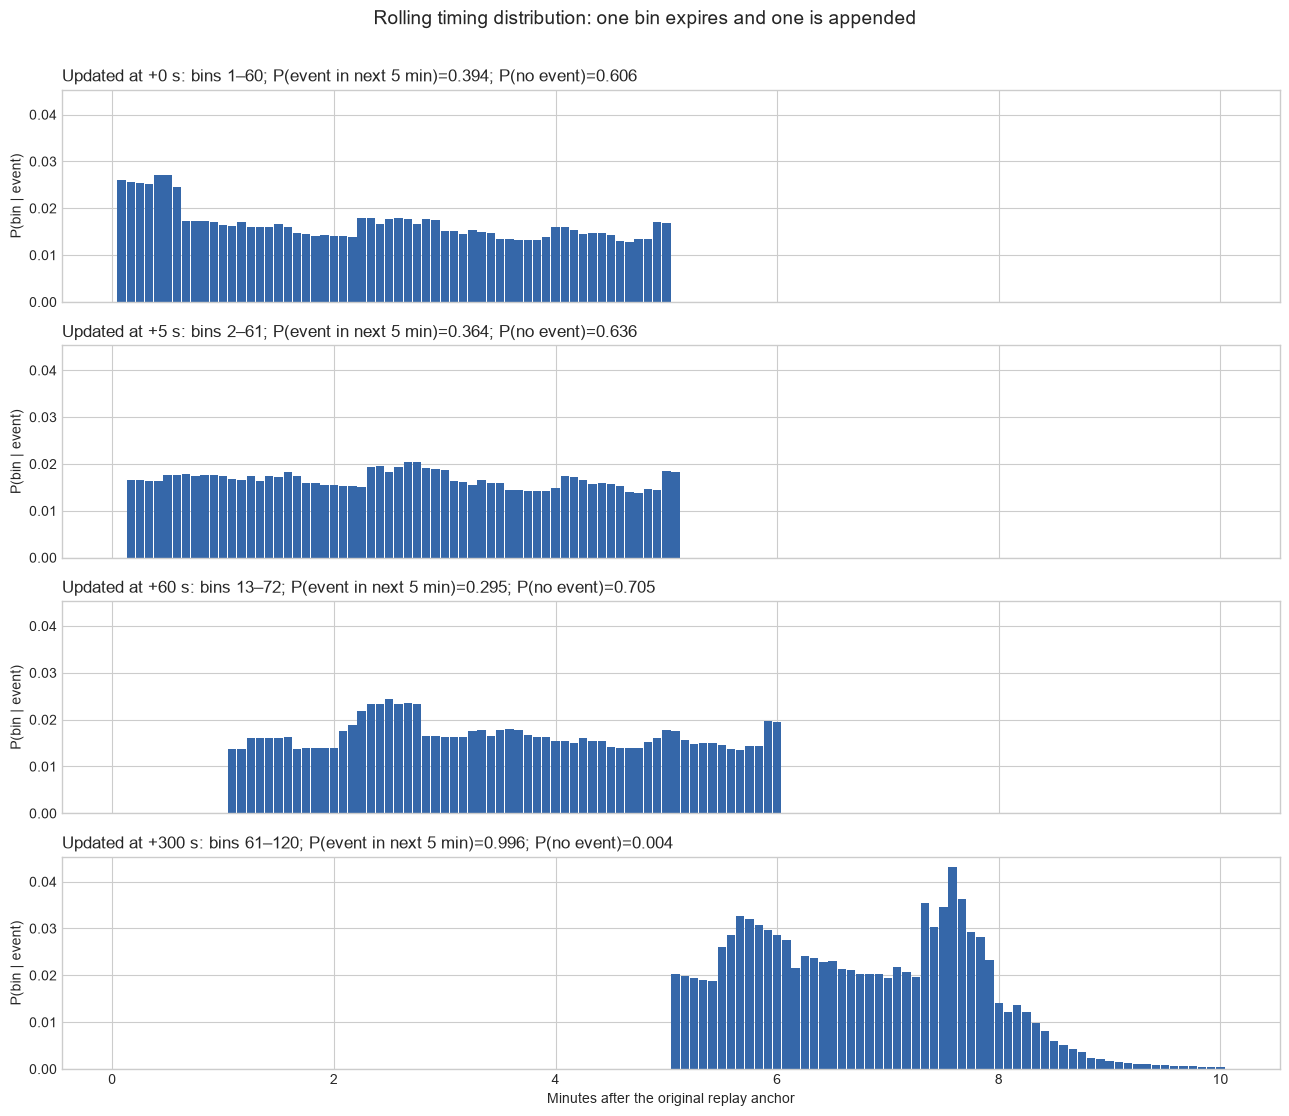

,absolute_episode_bin,interval_start_seconds,interval_end_seconds,seconds_ahead_start,seconds_ahead_end,onset_probability,timing_probability_given_event,cumulative_onset_probability,survival_probability
0,2,5,10,0,5,0.006045,0.0166,0.0060,0.9940
1,3,10,15,5,10,0.006009,0.0165,0.0121,0.9879
2,4,15,20,10,15,0.005973,0.0164,0.0180,0.9820
3,5,20,25,15,20,0.005936,0.0163,0.0240,0.9760
4,6,25,30,20,25,0.006411,0.0176,0.0304,0.9696
5,7,30,35,25,30,0.006455,0.0177,0.0368,0.9632
6,8,35,40,30,35,0.006472,0.0178,0.0433,0.9567
7,9,40,45,35,40,0.006374,0.0175,0.0497,0.9503
8,10,45,50,40,45,0.006449,0.0177,0.0561,0.9439
9,11,50,55,45,50,0.006405,0.0176,0.0625,0.9375


At +5 s, onset mass over the next 5 min = 0.364228
At +5 s, no-event mass over the next 5 min = 0.635772
Total = 1.000000000000


In [8]:
states = [('0 s', state_0), ('5 s', state_5), ('60 s', state_60), ('300 s', state_300)]
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True, sharey=True)
rolling_rows = []
for axis, (label, state) in zip(axes, states, strict=True):
    table = state['probability_table'].copy()
    table['state_elapsed_seconds'] = state['episode_step'] * config.bin_seconds
    rolling_rows.append(table)
    axis.bar(
        table['interval_end_seconds'] / 60,
        table['timing_probability_given_event'],
        width=config.bin_seconds / 60 * 0.9,
        color='#3567A9',
    )
    axis.set_ylabel('P(bin | event)')
    axis.set_title(
        f'Updated at +{label}: bins {table["absolute_episode_bin"].iloc[0]}–{table["absolute_episode_bin"].iloc[-1]}; '
        f'P(event in next 5 min)={state["event_risk_next_5m"]:.3f}; '
        f'P(no event)={state["no_event_probability_next_5m"]:.3f}',
        loc='left',
    )
axes[-1].set_xlabel('Minutes after the original replay anchor')
fig.suptitle('Rolling timing distribution: one bin expires and one is appended', y=1.01, fontsize=14)
fig.tight_layout()
rolling_figure_path = paths['results'] / 'moving_horizon_rolling_example.png'
fig.savefig(rolling_figure_path, dpi=160, bbox_inches='tight')
plt.show()

rolling_output = pd.concat(rolling_rows, ignore_index=True)
rolling_output.to_csv(paths['results'] / 'moving_horizon_rolling_example.csv', index=False)
display(state_5['probability_table'].head(12).style.format({
    'onset_probability': '{:.6f}',
    'timing_probability_given_event': '{:.4f}',
    'cumulative_onset_probability': '{:.4f}',
    'survival_probability': '{:.4f}',
}))
print(f"At +5 s, onset mass over the next 5 min = {state_5['event_risk_next_5m']:.6f}")
print(f"At +5 s, no-event mass over the next 5 min = {state_5['no_event_probability_next_5m']:.6f}")
print(f"Total = {state_5['event_risk_next_5m'] + state_5['no_event_probability_next_5m']:.12f}")

## 10. Weaknesses and inconsistencies

1. **Absolute probability is not identified by this sample.** The recordings were selected around seizures and the notebook deliberately matches one interictal episode per seizure. The resulting prevalence is artificial; probability calibration does not transfer to daily life.
2. **Only 47 seizures from 14 patients are available.** Sixty overlapping landmarks per event do not create 2,820 independent seizures. All splitting and interpretation must remain patient-grouped.
3. **False alarms/hour is unstable.** The selected interictal replay is short. A clinically useful estimate needs long, continuous, representative recordings including days without seizures.
4. **A rolling five-minute horizon creates overlapping forecasts.** Evaluation needs a prespecified update schedule plus rules for warning persistence, duplicate alarms, postictal exclusion, and refractory periods; treating all overlapping landmarks as independent would be pseudoreplication.
5. **Five-second bins imply interval censoring.** Onset labels and annotation repairs are not exact enough to justify interpreting differences smaller than a bin. Soft labels across neighboring bins would better reflect uncertainty.
6. **Two minutes is context, not online learning.** This stateless model does not “start understanding” during those minutes; it deterministically summarizes them using parameters learned from other recordings.
7. **Scalp EEG is artifact-prone and heterogeneous.** Low gamma is truncated to 30–45 Hz to avoid 60 Hz line noise and resampling limits. Sleep, medication, electrode montage, and hospital routine can confound apparent preictal changes.
8. **The current feature model is deliberately small.** It ignores electrode geometry and detailed phase/connectivity structure. A large neural network would overfit this dataset even more severely.
9. **Fresh forecasts need not be temporally coherent.** Re-estimation from new EEG can make adjacent probability curves jump. Temporal-consistency regularization can reduce this, but should not hide genuine signal changes.
10. **Conditional timing bars can look confident when event risk is tiny.** Always display the no-event probability and absolute event risk next to the timing-only graph.

## 11. Improvements within this framework

- Acquire long continuous scalp/subscalp EEG with complete seizure diaries, and preserve real censoring instead of constructing balanced controls.
- Use nested leave-one-patient-out or chronological validation. Select thresholds and calibrators only inside the development split; report patient bootstrap intervals and seizure-time surrogate tests.
- Calibrate the 61-outcome distribution on representative prevalence (temperature scaling, isotonic calibration, or Bayesian prior correction), then verify reliability separately by horizon and patient.
- Replace handcrafted summaries with a causal multichannel encoder only after substantially more independent patients and seizures are available. Keep the same hazard head and no-event mass.
- Add time-of-day, sleep stage, medication, and patient baseline as explicit covariates rather than allowing them to leak through uncontrolled recording context.
- Use soft onset targets across adjacent five-second bins and sensitivity analyses with 10-, 15-, or 30-second bins. Sixty output intervals may be too granular for 47 events.
- Add a temporal-consistency penalty between adjacent landmark survival curves, while allowing data-driven changes after new EEG is observed.
- Define operational rules before testing: warning duration, lockout, postictal exclusion, episode reset, and what counts as one false alarm.
- Compare against transparent baselines: constant patient seizure rate, time-of-day/cycle model, and a model using no EEG. Report Brier skill and improvement over seizure-time surrogates.
- Treat recurrent seizures with a recurrent-event/point-process extension when long recordings become available.

In [9]:
artifact_rows = []
for artifact in sorted(paths['results'].iterdir()):
    if artifact.is_file():
        artifact_rows.append({
            'file': artifact.name,
            'size_kb': round(artifact.stat().st_size / 1024, 1),
            'purpose': {
                'study_summary.csv': 'Readable study/data inventory',
                'episode_manifest.csv': 'Exact EDF episodes and anchors used',
                'holdout_metrics.csv': 'Overall holdout scores',
                'holdout_patient_metrics.csv': 'Per-patient holdout scores',
                'development_warning_curve.csv': 'Sensitivity/TiW threshold trade-off',
                'holdout_landmark_probabilities.csv': 'Every holdout landmark and all 60 bin probabilities',
                'rolling_discrete_hazard_model.joblib': 'Fitted model bundle and configuration',
                'forecast_evaluation.png': 'Calibration and warning trade-off plot',
                'moving_horizon_rolling_example.png': 'Four rolling 60-bin probability graphs',
                'moving_horizon_rolling_example.csv': 'Readable moving-horizon probability tables',
            }.get(artifact.name, 'Generated notebook artifact'),
        })
artifact_inventory = pd.DataFrame(artifact_rows)
artifact_inventory.to_csv(paths['results'] / 'ARTIFACT_INVENTORY.csv', index=False)
display(artifact_inventory)

display(Markdown(
    '### Completion check\n\n'
    f'- Read **{len(edf_files)} EDF files in the study inventory** and extracted features from **{len(manifest)} selected episodes**.\n'
    f'- Trained on **{len(split["development_patients"])} development patients** and evaluated on **{len(split["holdout_patients"])} unseen patients**.\n'
    f'- Verified nonnegative probabilities, monotone survival, and total mass of one.\n'
    f'- Saved the working model and readable CSV/PNG outputs to `{paths["results"]}`.\n\n'
    '**Conclusion:** the corrected discrete-hazard formulation is mathematically consistent. The implementation works as an offline research prototype, but this dataset cannot support calibrated clinical seizure warnings.'
))

,file,size_kb,purpose
0,ARTIFACT_INVENTORY.csv,0.8,Generated notebook artifact
1,development_warning_curve.csv,12.2,Sensitivity/TiW threshold trade-off
2,episode_manifest.csv,16.2,Exact EDF episodes and anchors used
3,forecast_evaluation.png,87.6,Calibration and warning trade-off plot
4,holdout_landmark_probabilities.csv,2612.8,Every holdout landmark and all 60 bin probabil...
5,holdout_metrics.csv,1.2,Overall holdout scores
6,holdout_patient_metrics.csv,0.4,Per-patient holdout scores
7,moving_horizon_rolling_example.csv,24.2,Readable moving-horizon probability tables
8,moving_horizon_rolling_example.png,106.0,Four rolling 60-bin probability graphs
9,rolling_discrete_hazard_model.joblib,333.9,Fitted model bundle and configuration


### Completion check

- Read **41 EDF files in the study inventory** and extracted features from **94 selected episodes**.
- Trained on **10 development patients** and evaluated on **4 unseen patients**.
- Verified nonnegative probabilities, monotone survival, and total mass of one.
- Saved the working model and readable CSV/PNG outputs to `C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-optimizers-analysis\final_project\results\rolling_forecast`.

**Conclusion:** the corrected discrete-hazard formulation is mathematically consistent. The implementation works as an offline research prototype, but this dataset cannot support calibrated clinical seizure warnings.

## 12. Reuse on another EDF landmark

After running the notebook, reload the saved bundle and instantiate the boundary-triggered engine. `episode_anchor_seconds` must be at least 120 seconds into the EDF. Set `replay_duration_seconds` to the prerecorded span over which scheduled forecast states should be cached; every state still predicts 300 seconds beyond its own landmark.

```python
bundle = joblib.load(paths['results'] / 'rolling_discrete_hazard_model.joblib')
engine = rsf.RollingForecastEngine(
    bundle['model'],
    edf_path='path/to/recording.edf',
    episode_anchor_seconds=600,
    config=bundle['config'],
    replay_duration_seconds=300,
)
forecast = engine.advance_to(600)     # returns precomputed state
same = engine.advance_to(604.9)       # cached; no update
updated = engine.advance_to(605.0)    # cached state: bin 1 expires, bin 61 is appended
display(updated['probability_table'])
```

Do not interpret the returned numbers as clinical probabilities without representative long-term data and external prospective validation.